# Skin Cancer Classification - 01: EDA

Classify dermatoscopic skin-lesion images into diagnosis categories. Dataset: **HAM10000** via HuggingFace `marmal88/skin_cancer`, 7 lesion types (melanoma, melanocytic nevi, basal-cell carcinoma, etc.). A committed 64x64 sample sits under `data/sample/<diagnosis>/`. Teaching demo, not a medical device.

In [1]:
import sys, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils
imgs, labels, classes = utils.load_sample()
print('classes:', len(classes)); print(classes)
print('total images:', len(imgs))

classes: 7
['actinic_keratoses', 'basal_cell_carcinoma', 'benign_keratosis-like_lesions', 'dermatofibroma', 'melanocytic_Nevi', 'melanoma', 'vascular_lesions']
total images: 1496


## 1. Class balance

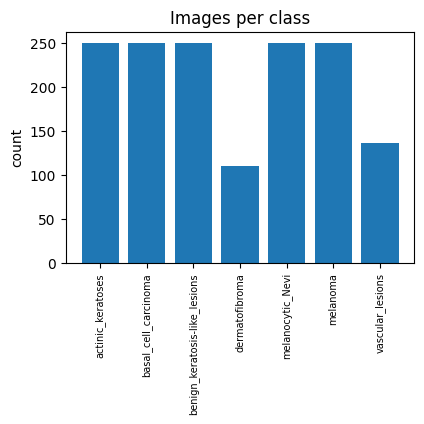

actinic_keratoses      250
basal_cell_carcinoma   250
benign_keratosis-like_lesions 250
dermatofibroma         110
melanocytic_Nevi       250
melanoma               250
vascular_lesions       136


In [2]:
import collections
cnt = collections.Counter(labels)
plt.figure(figsize=(min(14,1+len(classes)*0.5),3)); plt.bar(range(len(classes)), [cnt[c] for c in classes])
plt.xticks(range(len(classes)), classes, rotation=90, fontsize=7); plt.ylabel('count'); plt.title('Images per class'); plt.show()
for k in classes: print('%-22s %d' % (k, cnt[k]))

## 2. One sample per class

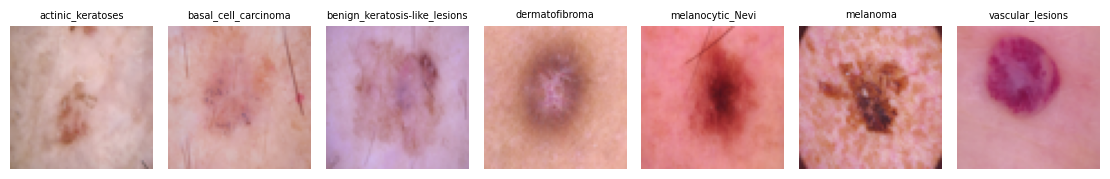

In [3]:
import math
n=len(classes); cols=min(n,10); rows=math.ceil(n/cols)
fig, ax = plt.subplots(rows, cols, figsize=(1.6*cols, 1.8*rows)); ax=np.atleast_2d(ax)
seen={}
for im,l in zip(imgs,labels):
    if l in seen: continue
    seen[l]=im
for i,cl in enumerate(classes):
    a=ax[i//cols][i%cols]; a.imshow(seen[cl]); a.set_title(cl, fontsize=7); a.axis('off')
for j in range(n, rows*cols): ax[j//cols][j%cols].axis('off')
plt.tight_layout(); plt.show()

### Findings
Seven diagnosis classes, heavily imbalanced in the source (melanocytic nevi dominate; dermatofibroma is rare). The lesions differ in colour, border, and texture, but several classes look alike to a non-expert.